<a href="https://colab.research.google.com/github/dasha3000/python-ai-Evdokimova-Daria/blob/main/notebooks/vizu_country_monument_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Неделя 3 — Анализ и визуализация / Week 3 — Analysis and visualization

### 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `monuments_country_style.csv` (414 записей о 337 памятниках)
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена
- Проверяем структуру данных и удаляем дубликаты

**Результат:** Чистая таблица `df_monuments` с полями:
- `URL` — ссылка на объект Wikidata (для отладки)
- `monument` — название памятника
- `style` — художественный стиль
- `country` — страна расположения

In [30]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем репозиторий
github_user = "dasha3000"
repo = "python-ai-Evdokimova-Daria"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с памятниками
df_monuments = pd.read_csv("data/monuments_country_style.csv")
print(f"📊 Загружено строк в df_monuments: {len(df_monuments)}\n")

# Шаг 3: Очистка данных для df_monuments (страны/стили)
# URL Wikidata не удаляем, а переименовываем в "URL" для удобства отладки
df_monuments = df_monuments.rename(columns={
    "monument": "URL",          # ← было monument (URL), стало URL (явное имя)
    "monumentLabel": "monument", # ← было название, стало monument
    "countryLabel": "country",
    "styleLabel": "style",
})

# Проверяем на пропущенные значения
print("✅ df_monuments очищен\n")

# Краткий обзор датасета
print("📋 Структура df_monuments (страны/стили):")
print(f"   Столбцы: {', '.join(df_monuments.columns)}")
print(f"   Уникальных памятников: {df_monuments['monument'].nunique()}")
print(f"   Уникальных стран: {df_monuments['country'].nunique()}")
print(f"   Уникальных стилей: {df_monuments['style'].nunique()}")

# Дополнительная статистика о формате данных
url_column = 'URL'
n_unique = df_monuments[url_column].nunique()
avg_styles = len(df_monuments) / n_unique

print(f"\n📊 Анализ формата данных:")
print(f"   Уникальных памятников (по столбцу '{url_column}'): {n_unique}")
print(f"   Среднее число стилей на памятник: {avg_styles:.1f}")

if avg_styles > 1.0:
    print(f"   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: {len(df_monuments)} строк = {n_unique} памятников × ~{avg_styles:.1f} стилей")
    print(f"   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)")
else:
    print(f"   ✅ Каждый памятник имеет ровно один стиль — формат простой")

print(f"\n🔍 Первые 3 строки df_monuments:\n{df_monuments.head(3)}")

✅ Репозиторий готов

📊 Загружено строк в df_monuments: 414

✅ df_monuments очищен

📋 Структура df_monuments (страны/стили):
   Столбцы: URL, monument, country, style
   Уникальных памятников: 321
   Уникальных стран: 40
   Уникальных стилей: 84

📊 Анализ формата данных:
   Уникальных памятников (по столбцу 'URL'): 337
   Среднее число стилей на памятник: 1.2
   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: 414 строк = 337 памятников × ~1.2 стилей
   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)

🔍 Первые 3 строки df_monuments:
                                        URL                       monument  \
0   http://www.wikidata.org/entity/Q3852976  Monument to cardinal De Braye   
1   http://www.wikidata.org/entity/Q3323370     Héloïse and Abélard's tomb   
2  http://www.wikidata.org/entity/Q11363889            Chūson-ji Konjikidō   

   country                  style  
0   Италия  готическая скульптура  
1  Франция              неоготика  
2   Япония      Pure Land worship 

## 🌐 [7] Bipartite Network Graph: Страны ↔ Стили

**Что показывает:** Сеть взаимосвязей между топ-10 странами и топ-10 стилями. Размер узла отражает количество памятников, цвет ребра — силу связи. Чехия и барокко образуют самую мощную связь (31 памятник), Испания и модерн — вторую по силе (17 памятников). Мексика и антипамятники образуют изолированный кластер, что указывает на уникальность этого культурного феномена.

**Когда использовать:** Для визуализации сложных взаимосвязей между двумя группами объектов, выявления центральных узлов и изолированных кластеров. Особенно полезен для понимания структуры культурных влияний.

**Библиотеки:** `networkx` (создание графа), `plotly.graph_objects` (интерактивная визуализация)

**Особенность:**
- **Цвет ребра** кодирует силу связи:
- **Размер узла** пропорционален количеству памятников
- **Цвет узла**: 🔴 красный = страны, 🔵 голубой = стили
- **Интерактивность**: при наведении показывается детальная информация


In [31]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77


In [32]:
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) через памятники

# Импорт библиотек для сетевого анализа
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем сетевую модель данных...")
print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных для сети
# Выбираем топ-10 стран и топ-10 стилей для читаемости
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Фильтруем данные для сети
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# Создаем граф
G = nx.Graph()

# Добавляем узлы с атрибутами
for country in top10_countries:
    G.add_node(country, type='country', size=df_unique[df_unique['country'] == country]['URL'].nunique())

for style in top10_styles:
    G.add_node(style, type='style', size=df_unique[df_unique['style'] == style]['URL'].nunique())

# Добавляем ребра (связи через памятники)
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
    else:
        G.add_edge(row['country'], row['style'], weight=1)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# Подготовка данных для plotly с цветовой кодировкой ребер
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)

# Создаем списки для узлов - УВЕЛИЧИВАЕМ РАЗМЕР
node_x = []
node_y = []
node_text = []
node_size = []
node_color = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Связей: {G.degree(node)}<br>Памятников: {G.nodes[node]['size']}")
    node_size.append(G.nodes[node]['size'] * 25)  # Увеличено с 15 до 25

    # Цвет в зависимости от типа
    if G.nodes[node]['type'] == 'country':
        node_color.append('lightcoral')
    else:
        node_color.append('lightblue')

# Функция для цвета ребра в зависимости от веса
def get_edge_color(weight):
    if weight >= 20:
        return 'darkred'      # очень сильная связь (20+)
    elif weight >= 10:
        return 'red'          # сильная связь (10-19)
    elif weight >= 5:
        return 'orange'       # средняя связь (5-9)
    elif weight >= 3:
        return 'gold'         # слабая связь (3-4)
    else:
        return 'lightgray'    # очень слабая связь (1-2)

# СОЗДАЕМ ОБЪЕКТ FIG ПЕРЕД ЦИКЛОМ
fig = go.Figure()

# Создаем ребра с цветовой кодировкой
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    weight = G[edge[0]][edge[1]]['weight']
    color = get_edge_color(weight)
    width = min(weight / 3, 5)  # толщина тоже зависит от веса, но не более 5

    # Добавляем ребро
    fig.add_trace(go.Scatter(
        x=[x0, x1], y=[y0, y1],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        hovertext=f"{edge[0]} → {edge[1]}<br>Связей: {weight} памятников",
        showlegend=False
    ))

# Добавляем узлы
fig.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    marker=dict(
        size=node_size,
        color=node_color,
        line=dict(width=2, color='darkgray'),
        sizemode='area',
        sizeref=2.*max(node_size)/(40.**2),
        sizemin=8
    ),
    text=[n for n in G.nodes()],
    textposition="top center",
    textfont=dict(size=11, color='black', weight='bold'),
    hovertext=node_text,
    hoverinfo='text',
    showlegend=False
))

# Добавляем легенду для ребер
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='darkred', width=3), name='Очень сильная связь (20+ памятников)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='red', width=3), name='Сильная связь (10-19)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='orange', width=3), name='Средняя связь (5-9)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='gold', width=3), name='Слабая связь (3-4)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='lightgray', width=3), name='Очень слабая связь (1-2)'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightcoral', size=15), name='Страны'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightblue', size=15), name='Стили')
]

for trace in legend_traces:
    fig.add_trace(trace)

fig.update_layout(
    title={
        'text': "🌐 Сеть связей: Страны ↔ Стили (через памятники)<br><span style='font-size:12px'>Размер узла = количество памятников, Цвет ребра = сила связи</span>",
        'font': {'size': 18, 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True,
    legend=dict(
        x=1.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=10)
    ),
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=800,
    width=1200,
    plot_bgcolor='white'
)

fig.show()

print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура")
print("="*80)
print("""
🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый толстый и яркий поток (31 памятник) — темно-красный цвет!
   • Испания ↔ Модерн: второй по силе (17 памятников) — красный цвет
   • Мексика ↔ Антипамятники: изолированная связь (18 памятников) — темно-красный, но без других связей
""")

🌐 Создаем сетевую модель данных...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
✅ Для сети отобрано: 188 связей
   • 10 стран
   • 10 стилей
📊 Граф создан: 20 узлов, 24 ребер



🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура

🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый 

Статическая визуализация — используется matplotlib вместо plotly, без интерактивности

Стрелки направления — на основе среднего века памятников в каждой стране для данного стиля: если стиль появился раньше в одной стране и позже в другой, рисуется стрелка от ранней страны к стилю и от стиля к поздней

Кружки-дольки — каждый кружок (страна или стиль) представляет собой мини-круговую диаграмму (pie chart), показывающую распределение памятников по векам

Цветовая шкала — добавлена внизу графика, показывает соответствие цвета веку (синий — ранние, красный — поздние)

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77

📅 Загружаем данные с датами памятников...
✅ Загружено строк с датами: 567
📊 Памятников с определённым веком: 464
📊 Диапазон веков: -20 – 21

🌍 Топ-10 стран: ['Чехия', 'Испания', 'Италия', 'Германия', 'Мексика', 'Франция', 'Иран', 'Россия', 'Польша', 'Ватикан']
🎨 Топ-10 стилей: ['барокко', 'модерн', 'Anti-monuments in Mexico', 'социалистический реализм', 'классицизм', 'искусство Возрождения', 'ар-деко', 'неоклассицизм', 'Раннее Возрождение', 'рококо']

📏 Мин. расстояние между стилями: 0.185
   Мин. расстояние между странами: 0.260

🔍 Определяем направления распространения стилей...
   Раннее Возрождение: Германия (15.0 в.) → Италия (15.0 в.)
   барокко: Италия (14.6 в.) → Чехия (17.8 в.)
   искусство Возрождения: Франция (16.0 в.) → Германия (16.1 в.)
   классицизм: Франция (17.0 в.) → Чехия (19.0 в.)
   модерн: Испания (19.3 в.) → Польша (20.0 в.)
   неоклассиц

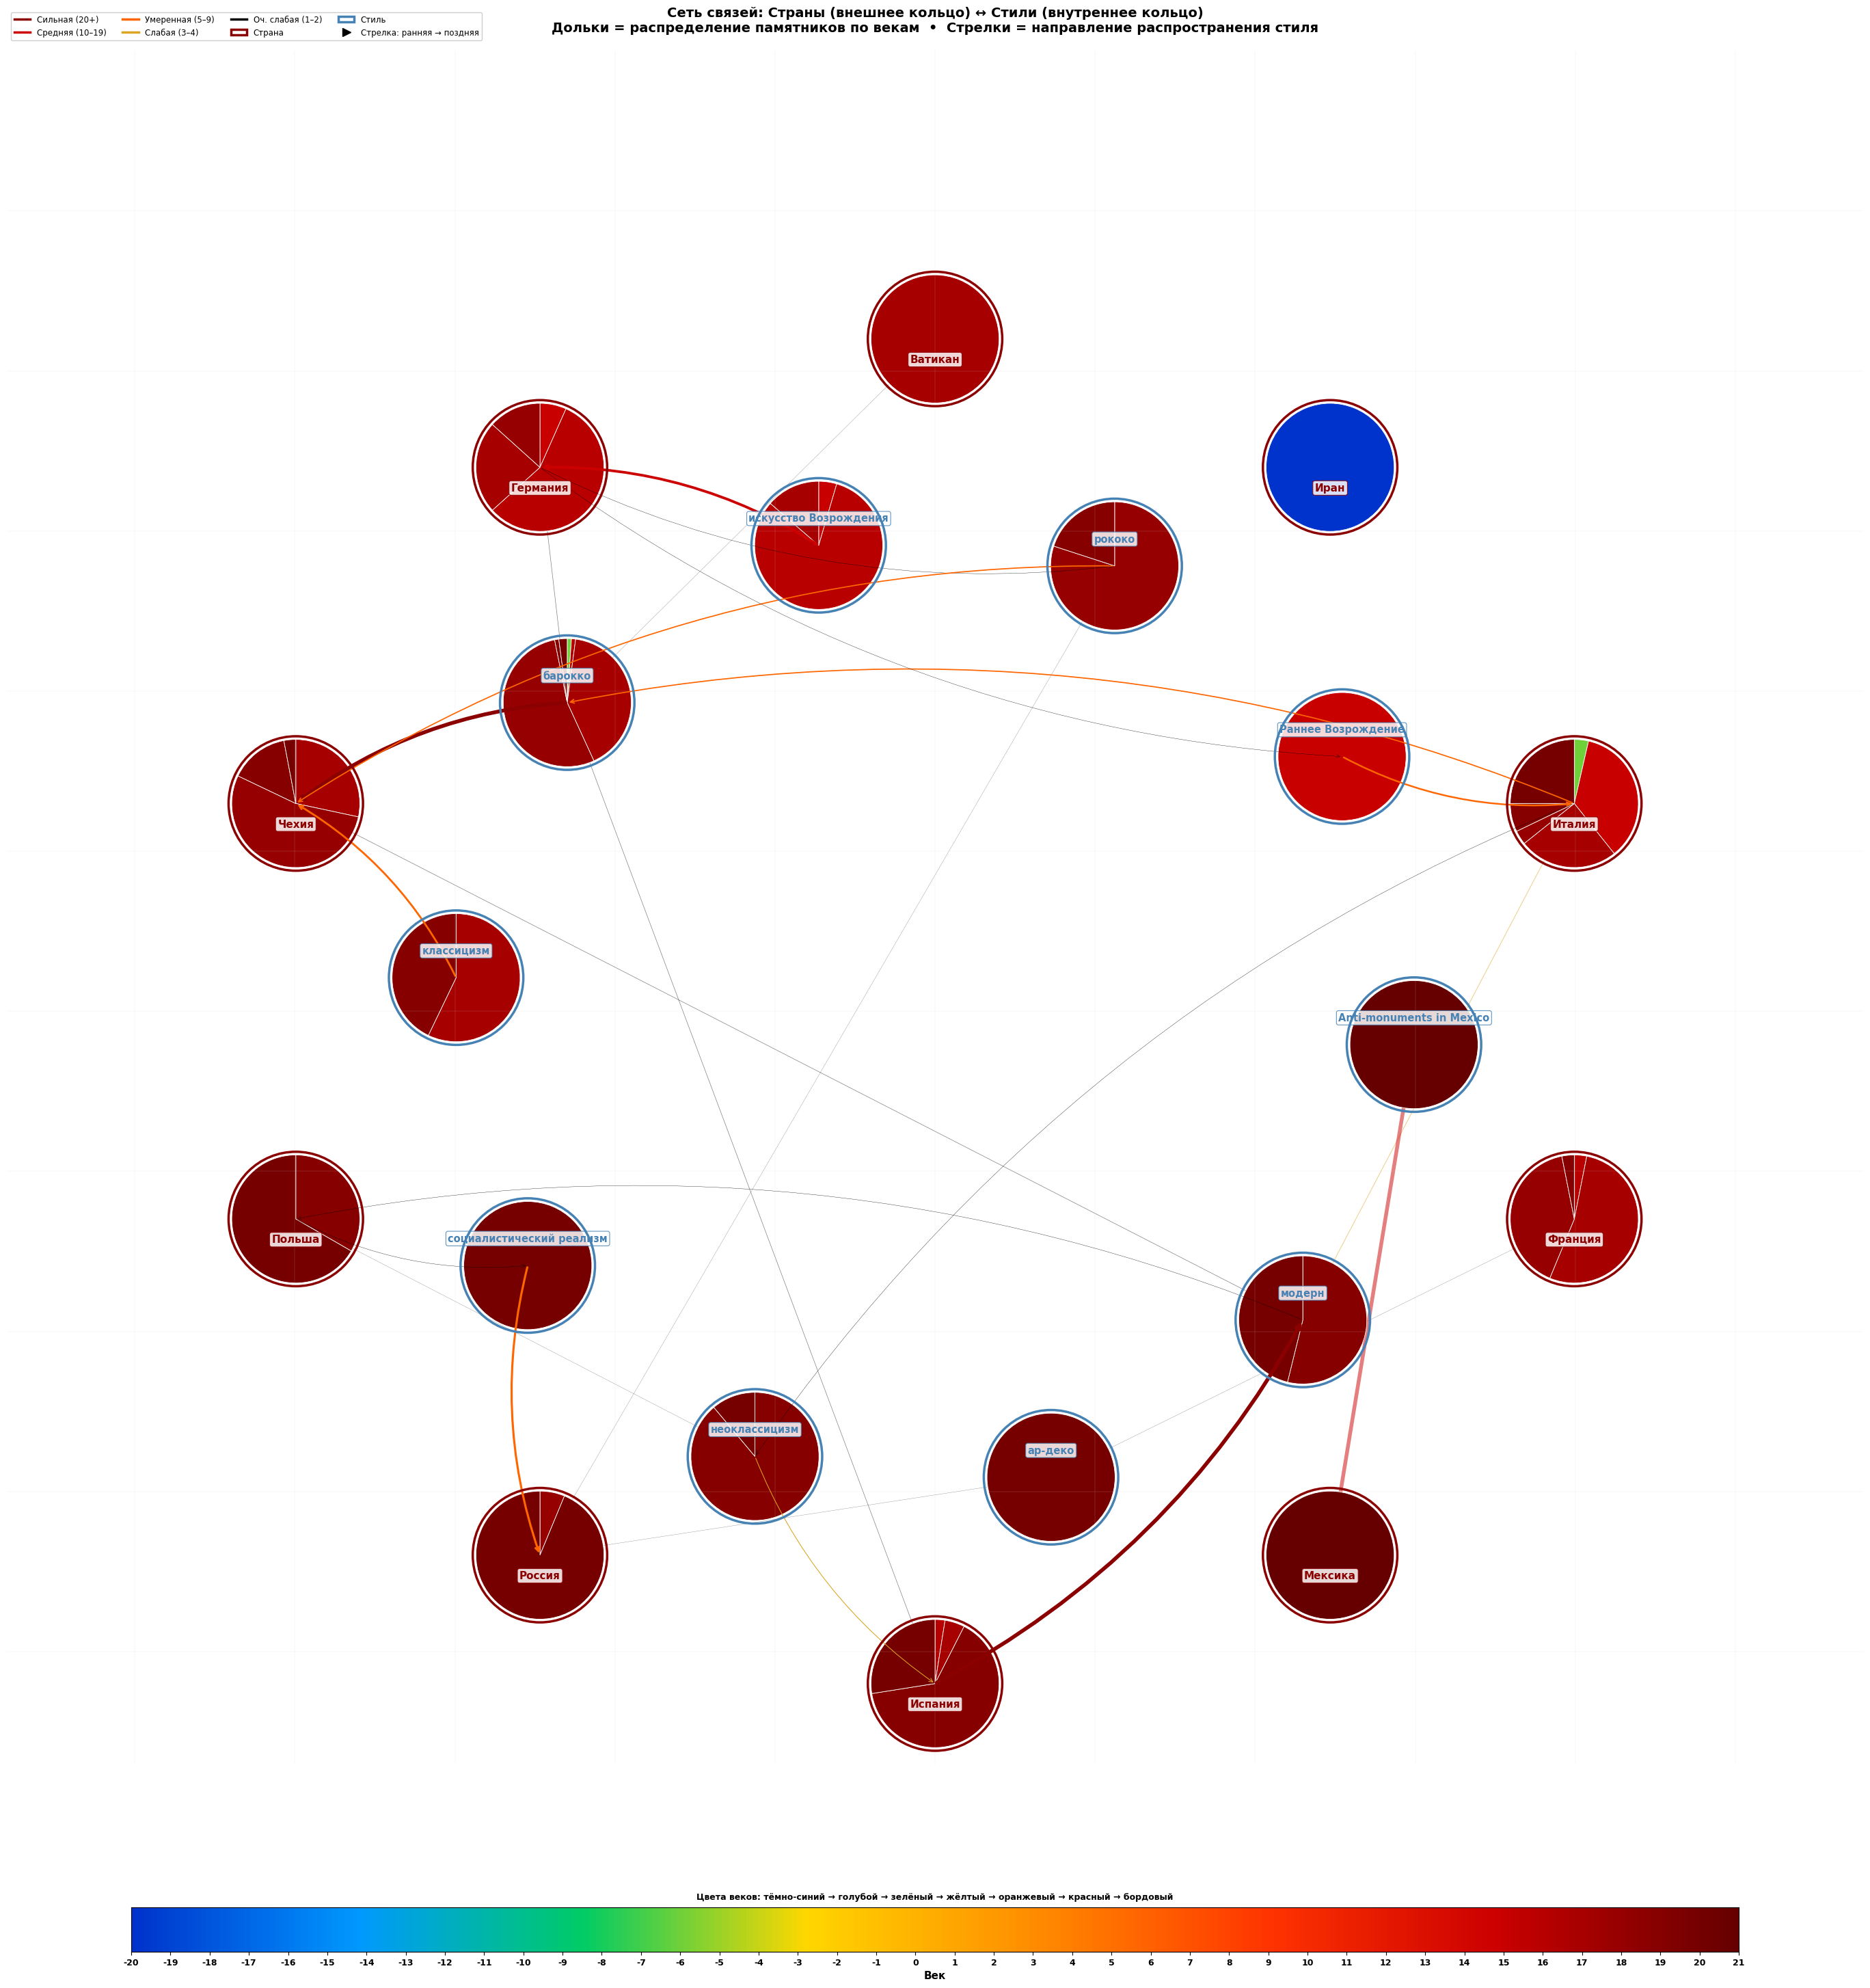


✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'

🔍 АНАЛИЗ СЕТИ

📐 СТРУКТУРА:
   • Внешнее кольцо: 10 стран (r=0.42)
   • Внутреннее кольцо: 10 стилей (r=0.30)
   • Всего рёбер: 24
   • Мин. расстояние стили: 0.185

🎯 НАПРАВЛЕНИЯ СТИЛЕЙ:
   Раннее Возрождение: Германия → Италия
      • Германия: ~15 век
      • Италия: ~15 век
   барокко: Италия → Чехия
      • Италия: ~15 век
      • Испания: ~17 век
      • Ватикан: ~17 век
      • Германия: ~17 век
      • Франция: ~18 век
      • Чехия: ~18 век
   искусство Возрождения: Франция → Германия
      • Франция: ~16 век
      • Германия: ~16 век
   классицизм: Франция → Чехия
      • Франция: ~17 век
      • Испания: ~19 век
      • Чехия: ~19 век
   модерн: Испания → Польша
      • Испания: ~19 век
      • Италия: ~20 век
      • Польша: ~20 век
   неоклассицизм: Италия → Испания
      • Италия: ~19 век
      • Польша: ~19 век
      • Франция: ~19 век
      • Испания: ~19 век
   рококо: Германия → Чехия
      • Г

In [54]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) со стрелками и кружками-дольками
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с датами
print("\n📅 Загружаем данные с датами памятников...")
df_dates = pd.read_csv("data/monuments_country_style_date.csv")
print(f"✅ Загружено строк с датами: {len(df_dates)}")

# Переименовываем колонки для совместимости
df_dates = df_dates.rename(columns={
    "monument": "URL",
    "monumentLabel": "monument",
    "countryLabel": "country",
    "styleLabel": "style",
    "inceptionYear": "date"
})

# Извлекаем век из даты
def extract_century(date_str):
    if pd.isna(date_str):
        return None
    import re
    if isinstance(date_str, (int, float)):
        year = int(date_str)
    else:
        numbers = re.findall(r'\d{3,4}', str(date_str))
        if not numbers:
            return None
        year = int(numbers[0])
    if year == 0:
        return None
    if year % 100 == 0:
        century = year // 100
    else:
        century = year // 100 + 1
    return century

df_dates['century'] = df_dates['date'].apply(extract_century)
df_dates = df_dates.dropna(subset=['century'])
df_dates['century'] = df_dates['century'].astype(int)

print(f"📊 Памятников с определённым веком: {len(df_dates)}")
print(f"📊 Диапазон веков: {df_dates['century'].min()} – {df_dates['century'].max()}")

# ============================================================
# Топ-10 стран и стилей
# ============================================================
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

print(f"\n🌍 Топ-10 стран: {top10_countries}")
print(f"🎨 Топ-10 стилей: {top10_styles}")

# ============================================================
# ГЕОГРАФИЧЕСКИЕ КООРДИНАТЫ СТРАН
# ============================================================
country_coords_geo = {
    'Россия':        (0.78, 0.78),
    'Германия':      (0.25, 0.58),
    'Франция':       (0.10, 0.45),
    'Италия':        (0.22, 0.28),
    'Испания':       (0.05, 0.18),
    'Чехия':         (0.32, 0.52),
    'Польша':        (0.48, 0.62),
    'Украина':       (0.62, 0.50),
    'Великобритания':(0.08, 0.65),
    'США':           (0.12, 0.85),
    'Мексика':       (0.08, 0.10),
    'Нидерланды':    (0.16, 0.55),
    'Австрия':       (0.28, 0.40),
    'Бельгия':       (0.12, 0.52),
    'Швейцария':     (0.18, 0.36),
    'Швеция':        (0.38, 0.85),
    'Норвегия':      (0.28, 0.88),
    'Дания':         (0.24, 0.75),
    'Финляндия':     (0.55, 0.88),
    'Греция':        (0.48, 0.12),
    'Турция':        (0.65, 0.08),
    'Япония':        (0.92, 0.48),
    'Китай':         (0.85, 0.38),
    'Индия':         (0.75, 0.18),
    'Бразилия':      (0.22, 0.06),
    'Аргентина':     (0.15, 0.04),
    'Канада':        (0.08, 0.92),
    'Австралия':     (0.90, 0.08),
    'Египет':        (0.58, 0.06),
    'Венгрия':       (0.42, 0.46),
}

def get_country_geo(country):
    if country in country_coords_geo:
        return country_coords_geo[country]
    seed = sum(ord(c) for c in country)
    np.random.seed(seed)
    return (np.random.uniform(0.1, 0.9), np.random.uniform(0.1, 0.9))

# ============================================================
# РАВНОМЕРНОЕ РАСПРЕДЕЛЕНИЕ С ОТТАЛКИВАНИЕМ СТИЛЕЙ
# ============================================================
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

def create_balanced_layout(countries, styles, network_data,
                           outer_radius=0.42, inner_radius=0.30,
                           center=(0.50, 0.50)):
    positions = {}
    center_x, center_y = center

    # === ВНЕШНЕЕ КОЛЬЦО: СТРАНЫ ===
    country_geo = {c: get_country_geo(c) for c in countries}

    sorted_countries = sorted(countries,
        key=lambda c: country_geo[c][0] + country_geo[c][1] * 0.3)

    n_countries = len(sorted_countries)

    for i, country in enumerate(sorted_countries):
        angle = (2 * np.pi * i / n_countries) - np.pi/2
        x = center_x + outer_radius * np.cos(angle)
        y = center_y + outer_radius * np.sin(angle)
        positions[country] = (x, y)

    # === ВНУТРЕННЕЕ КОЛЬЦО: СТИЛИ (с отталкиванием) ===
    style_country_map = {}
    for _, row in network_data.iterrows():
        c = row['country']
        s = row['style']
        if c in countries and s in styles:
            if s not in style_country_map:
                style_country_map[s] = []
            style_country_map[s].append(c)

    n_styles = len(styles)

    style_initial = {}
    for style in styles:
        if style in style_country_map and len(style_country_map[style]) > 0:
            linked = [c for c in style_country_map[style] if c in positions]
            if linked:
                angles = []
                for c in linked:
                    dx = positions[c][0] - center_x
                    dy = positions[c][1] - center_y
                    angles.append(np.arctan2(dy, dx))
                avg_angle = np.mean(angles)
            else:
                avg_angle = 2 * np.pi * styles.index(style) / n_styles - np.pi/2
        else:
            avg_angle = 2 * np.pi * styles.index(style) / n_styles - np.pi/2

        style_initial[style] = avg_angle

    style_angles = style_initial.copy()

    for iteration in range(50):
        sorted_by_angle = sorted(styles, key=lambda s: style_angles[s])

        for i in range(n_styles):
            prev_idx = (i - 1) % n_styles
            next_idx = (i + 1) % n_styles

            curr = sorted_by_angle[i]
            prev = sorted_by_angle[prev_idx]
            next_s = sorted_by_angle[next_idx]

            curr_angle = style_angles[curr]
            prev_angle = style_angles[prev]
            next_angle = style_angles[next_s]

            if prev_angle > curr_angle:
                prev_angle -= 2 * np.pi
            if next_angle < curr_angle:
                next_angle += 2 * np.pi

            min_angle = 2 * np.pi / n_styles * 1.1

            if curr_angle - prev_angle < min_angle:
                style_angles[curr] += (min_angle - (curr_angle - prev_angle)) * 0.3
            if next_angle - curr_angle < min_angle:
                style_angles[curr] -= (min_angle - (next_angle - curr_angle)) * 0.3

    for style in styles:
        angle = style_angles[style] % (2 * np.pi)
        x = center_x + inner_radius * np.cos(angle)
        y = center_y + inner_radius * np.sin(angle)
        positions[style] = (x, y)

    return positions

all_positions = create_balanced_layout(top10_countries, top10_styles, network_data)
country_pos = {k: v for k, v in all_positions.items() if k in top10_countries}
style_pos = {k: v for k, v in all_positions.items() if k in top10_styles}

# ПРОВЕРКА РАССТОЯНИЙ
min_style_dist = float('inf')
for i, s1 in enumerate(top10_styles):
    for s2 in top10_styles[i+1:]:
        p1 = style_pos[s1]
        p2 = style_pos[s2]
        d = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
        if d < min_style_dist:
            min_style_dist = d

min_country_dist = float('inf')
for i, c1 in enumerate(top10_countries):
    for c2 in top10_countries[i+1:]:
        p1 = country_pos[c1]
        p2 = country_pos[c2]
        d = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
        if d < min_country_dist:
            min_country_dist = d

print(f"\n📏 Мин. расстояние между стилями: {min_style_dist:.3f}")
print(f"   Мин. расстояние между странами: {min_country_dist:.3f}")

# ============================================================
# ОПРЕДЕЛЕНИЕ НАПРАВЛЕНИЯ СТРЕЛОК
# ============================================================
print("\n🔍 Определяем направления распространения стилей...")

df_network_dates = df_dates[
    df_dates['country'].isin(top10_countries) &
    df_dates['style'].isin(top10_styles)
].copy()

style_country_century = df_network_dates.groupby(['style', 'country'])['century'].mean().reset_index()
style_country_century.columns = ['style', 'country', 'avg_century']

style_centuries = defaultdict(dict)
for _, row in style_country_century.iterrows():
    style_centuries[row['style']][row['country']] = row['avg_century']

style_directions = {}
for style, country_centuries in style_centuries.items():
    if len(country_centuries) >= 2:
        sorted_countries = sorted(country_centuries.items(), key=lambda x: x[1])
        style_directions[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'centuries': country_centuries
        }
        print(f"   {style}: {sorted_countries[0][0]} ({sorted_countries[0][1]:.1f} в.) → {sorted_countries[-1][0]} ({sorted_countries[-1][1]:.1f} в.)")

# ============================================================
# ЦВЕТОВАЯ ШКАЛА
# ============================================================
min_century = int(df_dates['century'].min())
max_century = int(df_dates['century'].max())

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

colors_list = [
    (0.0,   '#0033CC'),
    (0.14,  '#0099FF'),
    (0.28,  '#00CC66'),
    (0.42,  '#FFD700'),
    (0.57,  '#FF8800'),
    (0.71,  '#FF3300'),
    (0.85,  '#CC0000'),
    (1.0,   '#660000'),
]

cmap = LinearSegmentedColormap.from_list('contrast_centuries', colors_list, N=256)

def century_to_color(century):
    if century is None or pd.isna(century):
        return 'lightgray'
    norm = (century - min_century) / max(1, (max_century - min_century))
    return mcolors.to_hex(cmap(norm))

# ============================================================
# ДАННЫЕ ДЛЯ КРУЖКОВ-ДОЛЕК
# ============================================================
country_century_dist = {}
for country in top10_countries:
    country_data = df_dates[
        (df_dates['country'] == country) &
        (df_dates['style'].isin(top10_styles))
    ]
    century_counts = country_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        country_century_dist[country] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        country_century_dist[country] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

style_century_dist = {}
for style in top10_styles:
    style_data = df_dates[
        (df_dates['style'] == style) &
        (df_dates['country'].isin(top10_countries))
    ]
    century_counts = style_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        style_century_dist[style] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        style_century_dist[style] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

# ============================================================
# РИСУЕМ ГРАФ
# ============================================================
print("\n🎨 Рисуем финальную визуализацию...")

fig, ax = plt.subplots(1, 1, figsize=(28, 26))
ax.set_facecolor('#FAFAFA')

# Тонкая сетка
for val in np.arange(0, 1.01, 0.1):
    ax.axvline(val, color='lightgray', linewidth=0.3, alpha=0.4)
    ax.axhline(val, color='lightgray', linewidth=0.3, alpha=0.4)

# ==== РЁБРА ====
edge_data = []
for _, row in network_data.iterrows():
    country = row['country']
    style = row['style']
    if country in country_pos and style in style_pos:
        edge_data.append((country, style))

edge_weights = Counter(edge_data)

def get_edge_color(weight):
    if weight >= 20:   return '#8B0000'
    elif weight >= 10: return '#CC0000'
    elif weight >= 5:  return '#FF6600'
    elif weight >= 3:  return '#DAA520'
    else:              return '#000000'  # БЫЛО #BBBBBB → стало ЯРЧЕ

drawn_edges = set()
for (country, style), weight in edge_weights.items():
    if (country, style) in drawn_edges or (style, country) in drawn_edges:
        continue
    drawn_edges.add((country, style))

    x1, y1 = country_pos[country]
    x2, y2 = style_pos[style]

    color = get_edge_color(weight)
    lw = min(weight / 4, 4)

    is_directed = False
    arrow_direction = None

    if style in style_directions:
        dir_info = style_directions[style]
        if dir_info['earliest'] != dir_info['latest']:
            is_directed = True
            if country == dir_info['earliest']:
                arrow_direction = 'from_country_to_style'
            elif country == dir_info['latest']:
                arrow_direction = 'from_style_to_country'

    if is_directed and arrow_direction == 'from_country_to_style':
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'))
    elif is_directed and arrow_direction == 'from_style_to_country':
        ax.annotate('', xy=(x1, y1), xytext=(x2, y2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'))
    else:
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, alpha=0.5, zorder=1)

# ==== КРУЖКИ-ДОЛЬКИ: СТРАНЫ (внешнее кольцо) ====
country_pie_radius = 0.04

for country in top10_countries:
    cx, cy = country_pos[country]
    dist = country_century_dist[country]

    if dist['total'] > 0:
        ax.pie(
            dist['counts'],
            radius=country_pie_radius,
            center=(cx, cy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.6)
        )

    circle = plt.Circle((cx, cy), country_pie_radius + 0.002, fill=False,
                        edgecolor='darkred', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

        # Подпись снаружи кружка — ШРИФТ 11
    ax.annotate(country, (cx, cy),
                textcoords="offset points", xytext=(0, -25),
                ha='center', fontsize=11, fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                         alpha=0.85, edgecolor='darkred', linewidth=0.8))


# ==== КРУЖКИ-ДОЛЬКИ: СТИЛИ (внутреннее кольцо) ====
style_pie_radius = 0.04

for style in top10_styles:
    sx, sy = style_pos[style]
    dist = style_century_dist[style]

    if dist['total'] > 0:
        ax.pie(
            dist['counts'],
            radius=style_pie_radius,
            center=(sx, sy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.6)
        )

    circle = plt.Circle((sx, sy), style_pie_radius + 0.002, fill=False,
                        edgecolor='steelblue', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

     # Подпись снаружи кружка — ШРИФТ 10.5
    ax.annotate(style, (sx, sy),
                textcoords="offset points", xytext=(0, 25),
                ha='center', fontsize=10.5, fontweight='bold', color='steelblue',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                         alpha=0.85, edgecolor='steelblue', linewidth=0.8))

# ==== ЦВЕТОВАЯ ШКАЛА — ЕЩЁ НИЖЕ ====
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

# Шкала теперь на y=-0.01 (за пределами основного графика)
ax_colorbar = fig.add_axes([0.08, -0.1, 0.84, 0.025])
ax_colorbar.imshow(gradient, aspect='auto', cmap=cmap,
                   extent=[min_century, max_century, 0, 1])
ax_colorbar.set_yticks([])

all_centuries = list(range(min_century, max_century + 1))
ax_colorbar.set_xticks(all_centuries)
ax_colorbar.set_xticklabels([str(c) for c in all_centuries],
                            fontsize=9, fontweight='bold')
ax_colorbar.set_xlabel('Век', fontsize=11, fontweight='bold')
ax_colorbar.set_title(
    'Цвета веков: тёмно-синий → голубой → зелёный → жёлтый → оранжевый → красный → бордовый',
    fontsize=9, pad=8, fontweight='bold')

# ==== ЛЕГЕНДА ====
legend_elements = [
    Line2D([0], [0], color='#8B0000', lw=2.5, label='Сильная (20+)'),
    Line2D([0], [0], color='#CC0000', lw=2.5, label='Средняя (10–19)'),
    Line2D([0], [0], color='#FF6600', lw=2.5, label='Умеренная (5–9)'),
    Line2D([0], [0], color='#DAA520', lw=2.5, label='Слабая (3–4)'),
    Line2D([0], [0], color='#000000', lw=2.5, label='Оч. слабая (1–2)'),
    mpatches.Patch(facecolor='white', edgecolor='darkred', linewidth=2.5, label='Страна'),
    mpatches.Patch(facecolor='white', edgecolor='steelblue', linewidth=2.5, label='Стиль'),
    Line2D([0], [0], marker='>', color='black', lw=0, markerfacecolor='black',
           markersize=8, label='Стрелка: ранняя → поздняя'),
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=8.5,
          framealpha=0.95, ncol=4, bbox_to_anchor=(0.0, 1.025))

# ==== ЗАГОЛОВОК ====
ax.set_title(
    "Сеть связей: Страны (внешнее кольцо) ↔ Стили (внутреннее кольцо)\n"
    "Дольки = распределение памятников по векам  •  Стрелки = направление распространения стиля",
    fontsize=14, fontweight='bold', pad=20
)

ax.set_xlim(-0.08, 1.08)
# Поднимаем нижнюю границу ещё выше, так как шкала теперь за пределами
ax.set_ylim(0.03, 1.10)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_static_arrows_pie.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'")

# ============================================================
# ВЫВОД АНАЛИЗА
# ============================================================
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ")
print("="*80)
print(f"\n📐 СТРУКТУРА:")
print(f"   • Внешнее кольцо: {len(top10_countries)} стран (r=0.42)")
print(f"   • Внутреннее кольцо: {len(top10_styles)} стилей (r=0.30)")
print(f"   • Всего рёбер: {len(edge_weights)}")
print(f"   • Мин. расстояние стили: {min_style_dist:.3f}")

print("\n🎯 НАПРАВЛЕНИЯ СТИЛЕЙ:")
for style, dir_info in style_directions.items():
    if dir_info['earliest'] != dir_info['latest']:
        print(f"   {style}: {dir_info['earliest']} → {dir_info['latest']}")
        for country, century in sorted(dir_info['centuries'].items(), key=lambda x: x[1]):
            print(f"      • {country}: ~{century:.0f} век")

 Вместо долек-пирогов рисуем концентрические кольца (как годичные кольца дерева).

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77

📅 Загружаем данные с датами памятников...
✅ Загружено строк с датами: 567
📊 Памятников с определённым веком: 464
📊 Диапазон веков: -20 – 21

🌍 Топ-10 стран: ['Чехия', 'Испания', 'Италия', 'Германия', 'Мексика', 'Франция', 'Иран', 'Россия', 'Польша', 'Ватикан']
🎨 Топ-10 стилей: ['барокко', 'модерн', 'Anti-monuments in Mexico', 'социалистический реализм', 'классицизм', 'искусство Возрождения', 'ар-деко', 'неоклассицизм', 'Раннее Возрождение', 'рококо']

📏 Мин. расстояние между стилями: 0.185
   Мин. расстояние между странами: 0.247

🔍 Определяем направления распространения стилей...
   Раннее Возрождение: Германия (15.0 в.) → Италия (15.0 в.)
   барокко: Италия (14.6 в.) → Чехия (17.8 в.)
   искусство Возрождения: Франция (16.0 в.) → Германия (16.1 в.)
   классицизм: Франция (17.0 в.) → Чехия (19.0 в.)
   модерн: Испания (19.3 в.) → Польша (20.0 в.)
   неоклассиц

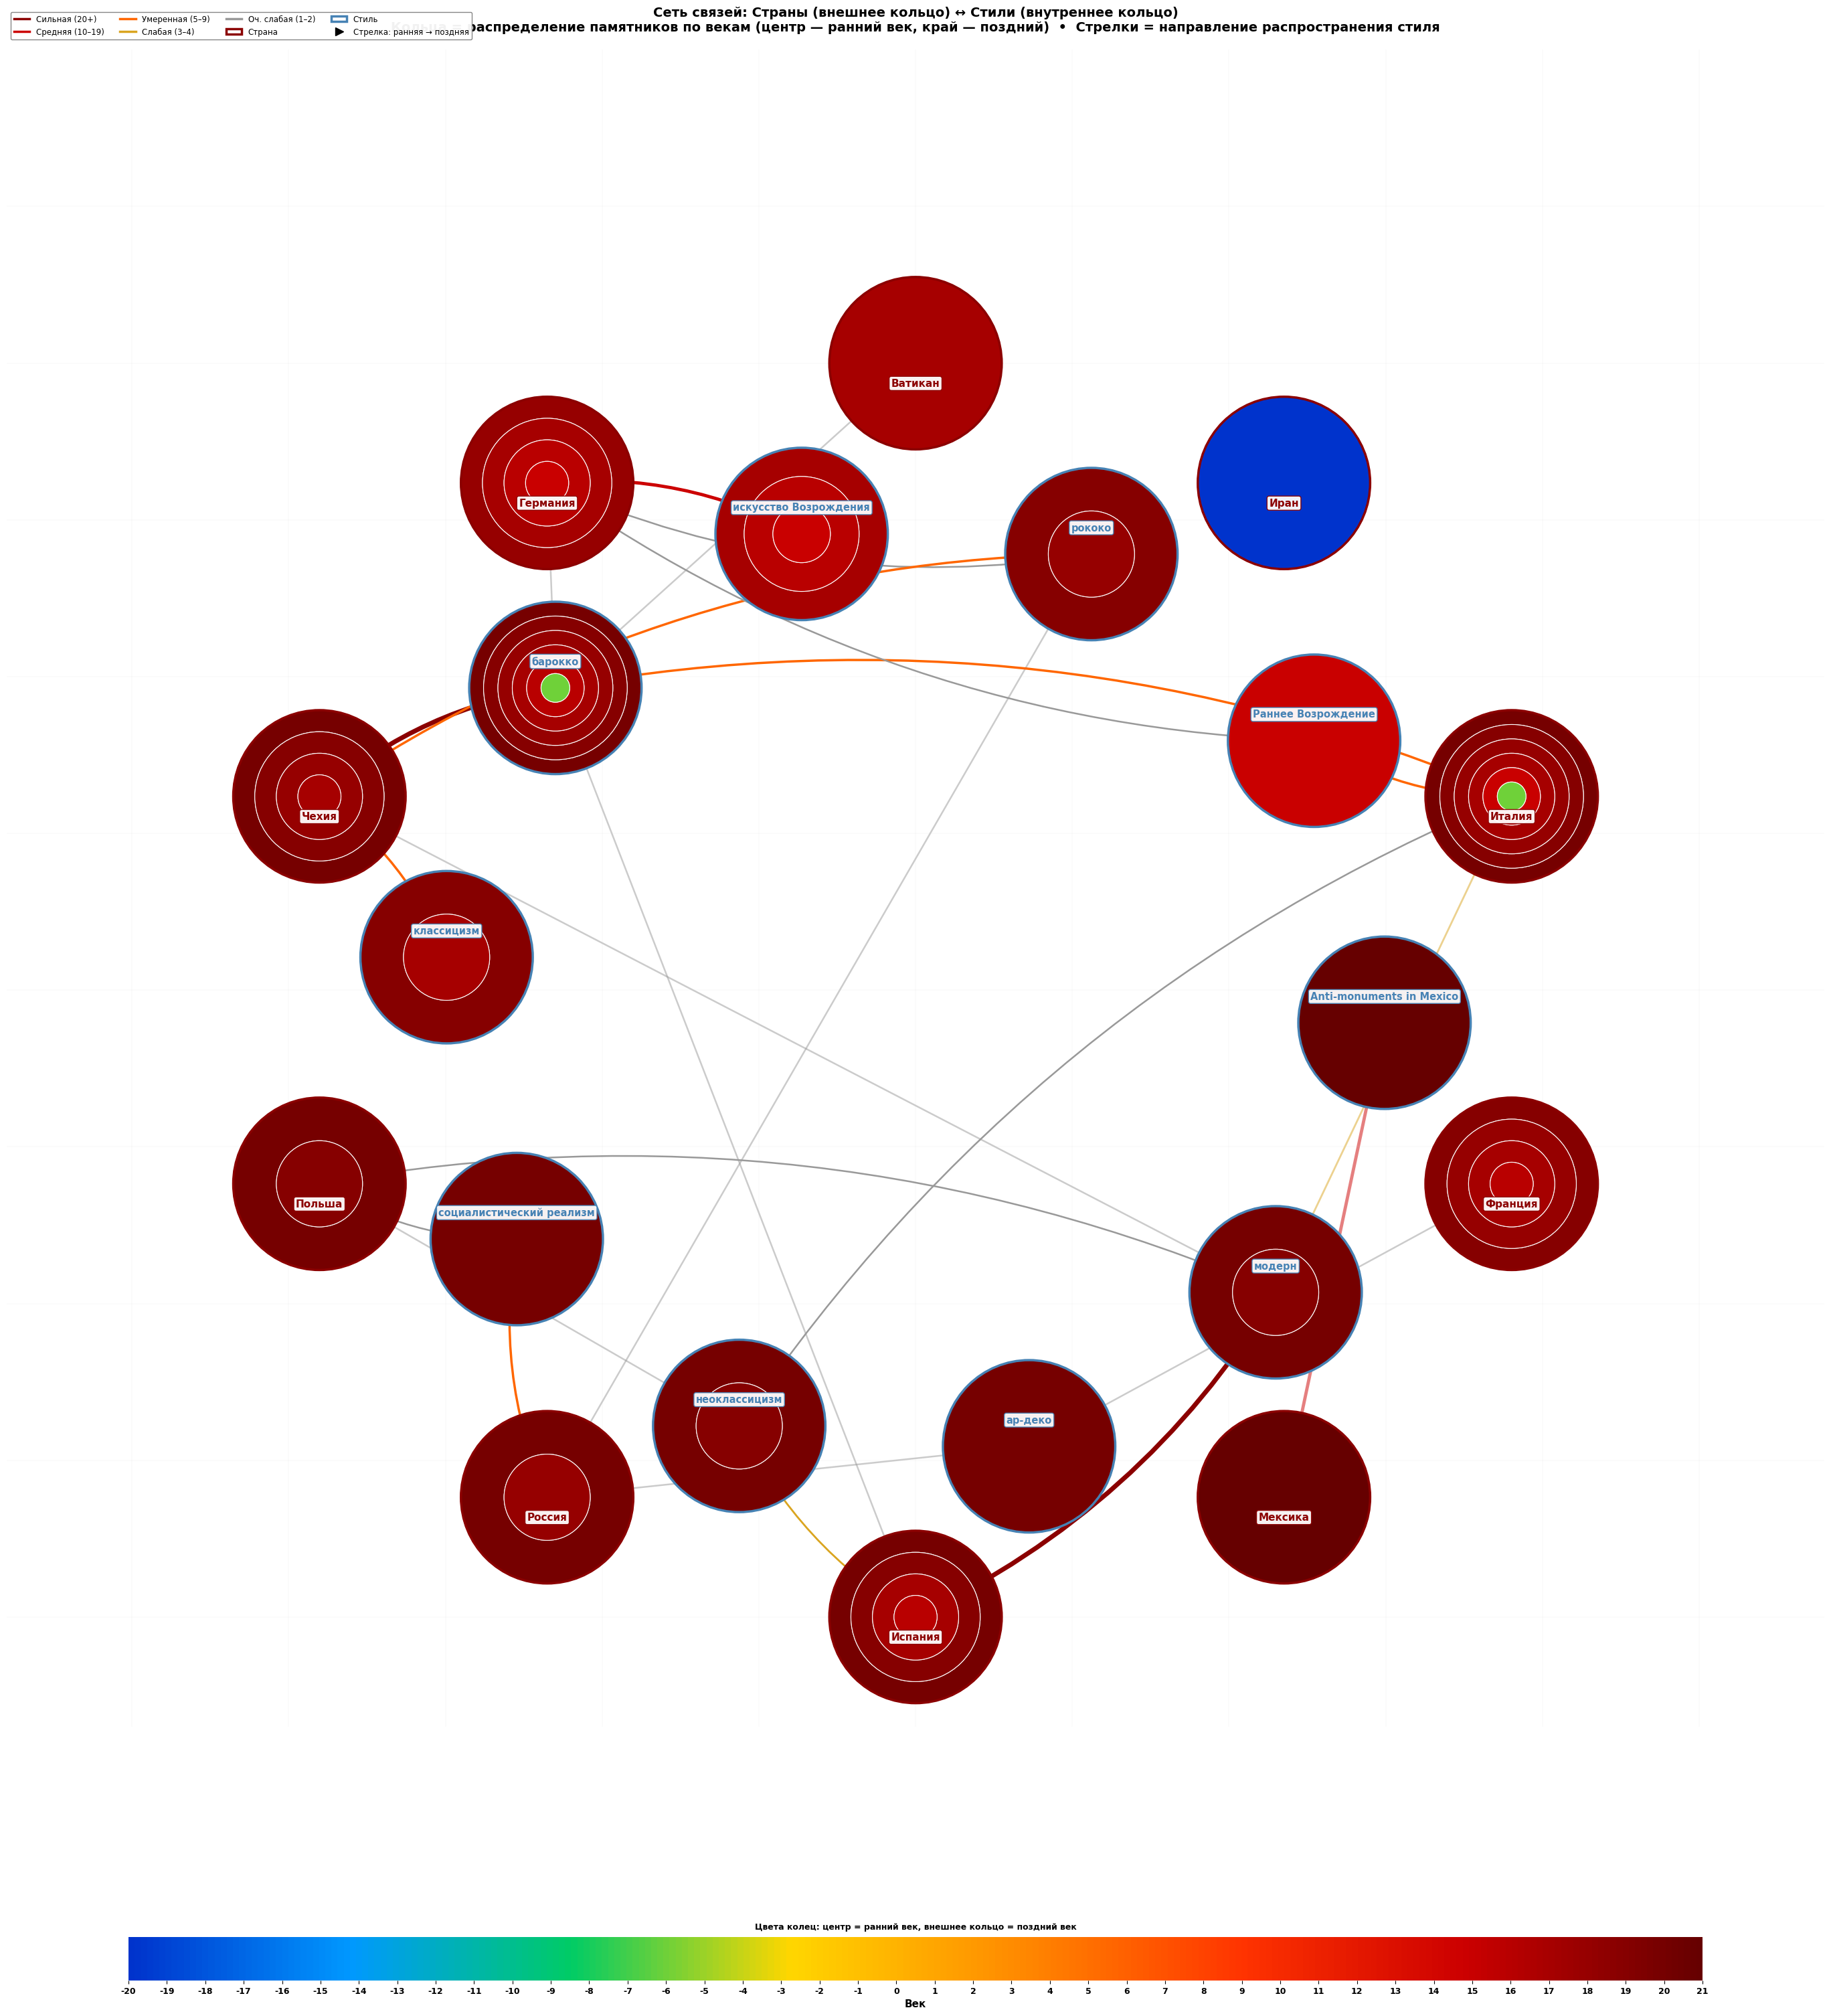


✅ Статическая визуализация сохранена как 'network_static_tree_rings.png'

🔍 АНАЛИЗ СЕТИ

📐 СТРУКТУРА:
   • Внешнее кольцо: 10 стран (r=0.40)
   • Внутреннее кольцо: 10 стилей (r=0.30)
   • Всего рёбер: 24
   • Мин. расстояние стили: 0.185
   • Мин. расстояние страны: 0.247

🎯 НАПРАВЛЕНИЯ СТИЛЕЙ:
   Раннее Возрождение: Германия → Италия
      • Германия: ~15 век
      • Италия: ~15 век
   барокко: Италия → Чехия
      • Италия: ~15 век
      • Испания: ~17 век
      • Ватикан: ~17 век
      • Германия: ~17 век
      • Франция: ~18 век
      • Чехия: ~18 век
   искусство Возрождения: Франция → Германия
      • Франция: ~16 век
      • Германия: ~16 век
   классицизм: Франция → Чехия
      • Франция: ~17 век
      • Испания: ~19 век
      • Чехия: ~19 век
   модерн: Испания → Польша
      • Испания: ~19 век
      • Италия: ~20 век
      • Польша: ~20 век
   неоклассицизм: Италия → Испания
      • Италия: ~19 век
      • Польша: ~19 век
      • Франция: ~19 век
      • Испания: ~19 век
  

In [67]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) со стрелками и кольцами-деревьями
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с датами
print("\n📅 Загружаем данные с датами памятников...")
df_dates = pd.read_csv("data/monuments_country_style_date.csv")
print(f"✅ Загружено строк с датами: {len(df_dates)}")

# Переименовываем колонки для совместимости
df_dates = df_dates.rename(columns={
    "monument": "URL",
    "monumentLabel": "monument",
    "countryLabel": "country",
    "styleLabel": "style",
    "inceptionYear": "date"
})

# Извлекаем век из даты
def extract_century(date_str):
    if pd.isna(date_str):
        return None
    import re
    if isinstance(date_str, (int, float)):
        year = int(date_str)
    else:
        numbers = re.findall(r'\d{3,4}', str(date_str))
        if not numbers:
            return None
        year = int(numbers[0])
    if year == 0:
        return None
    if year % 100 == 0:
        century = year // 100
    else:
        century = year // 100 + 1
    return century

df_dates['century'] = df_dates['date'].apply(extract_century)
df_dates = df_dates.dropna(subset=['century'])
df_dates['century'] = df_dates['century'].astype(int)

print(f"📊 Памятников с определённым веком: {len(df_dates)}")
print(f"📊 Диапазон веков: {df_dates['century'].min()} – {df_dates['century'].max()}")

# ============================================================
# Топ-10 стран и стилей
# ============================================================
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

print(f"\n🌍 Топ-10 стран: {top10_countries}")
print(f"🎨 Топ-10 стилей: {top10_styles}")

# ============================================================
# ГЕОГРАФИЧЕСКИЕ КООРДИНАТЫ СТРАН
# ============================================================
country_coords_geo = {
    'Россия':        (0.78, 0.78),
    'Германия':      (0.25, 0.58),
    'Франция':       (0.10, 0.45),
    'Италия':        (0.22, 0.28),
    'Испания':       (0.05, 0.18),
    'Чехия':         (0.32, 0.52),
    'Польша':        (0.48, 0.62),
    'Украина':       (0.62, 0.50),
    'Великобритания':(0.08, 0.65),
    'США':           (0.12, 0.85),
    'Мексика':       (0.08, 0.10),
    'Нидерланды':    (0.16, 0.55),
    'Австрия':       (0.28, 0.40),
    'Бельгия':       (0.12, 0.52),
    'Швейцария':     (0.18, 0.36),
    'Швеция':        (0.38, 0.85),
    'Норвегия':      (0.28, 0.88),
    'Дания':         (0.24, 0.75),
    'Финляндия':     (0.55, 0.88),
    'Греция':        (0.48, 0.12),
    'Турция':        (0.65, 0.08),
    'Япония':        (0.92, 0.48),
    'Китай':         (0.85, 0.38),
    'Индия':         (0.75, 0.18),
    'Бразилия':      (0.22, 0.06),
    'Аргентина':     (0.15, 0.04),
    'Канада':        (0.08, 0.92),
    'Австралия':     (0.90, 0.08),
    'Египет':        (0.58, 0.06),
    'Венгрия':       (0.42, 0.46),
}

def get_country_geo(country):
    if country in country_coords_geo:
        return country_coords_geo[country]
    seed = sum(ord(c) for c in country)
    np.random.seed(seed)
    return (np.random.uniform(0.1, 0.9), np.random.uniform(0.1, 0.9))

# ============================================================
# РАВНОМЕРНОЕ РАСПРЕДЕЛЕНИЕ С ОТТАЛКИВАНИЕМ СТИЛЕЙ
# ============================================================
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

def create_balanced_layout(countries, styles, network_data,
                           outer_radius=0.40, inner_radius=0.30,
                           center=(0.50, 0.50)):
    positions = {}
    center_x, center_y = center

    # === ВНЕШНЕЕ КОЛЬЦО: СТРАНЫ ===
    country_geo = {c: get_country_geo(c) for c in countries}

    sorted_countries = sorted(countries,
        key=lambda c: country_geo[c][0] + country_geo[c][1] * 0.3)

    n_countries = len(sorted_countries)

    for i, country in enumerate(sorted_countries):
        angle = (2 * np.pi * i / n_countries) - np.pi/2
        x = center_x + outer_radius * np.cos(angle)
        y = center_y + outer_radius * np.sin(angle)
        positions[country] = (x, y)

    # === ВНУТРЕННЕЕ КОЛЬЦО: СТИЛИ (с отталкиванием) ===
    style_country_map = {}
    for _, row in network_data.iterrows():
        c = row['country']
        s = row['style']
        if c in countries and s in styles:
            if s not in style_country_map:
                style_country_map[s] = []
            style_country_map[s].append(c)

    n_styles = len(styles)

    style_initial = {}
    for style in styles:
        if style in style_country_map and len(style_country_map[style]) > 0:
            linked = [c for c in style_country_map[style] if c in positions]
            if linked:
                angles = []
                for c in linked:
                    dx = positions[c][0] - center_x
                    dy = positions[c][1] - center_y
                    angles.append(np.arctan2(dy, dx))
                avg_angle = np.mean(angles)
            else:
                avg_angle = 2 * np.pi * styles.index(style) / n_styles - np.pi/2
        else:
            avg_angle = 2 * np.pi * styles.index(style) / n_styles - np.pi/2

        style_initial[style] = avg_angle

    style_angles = style_initial.copy()

    for iteration in range(50):
        sorted_by_angle = sorted(styles, key=lambda s: style_angles[s])

        for i in range(n_styles):
            prev_idx = (i - 1) % n_styles
            next_idx = (i + 1) % n_styles

            curr = sorted_by_angle[i]
            prev = sorted_by_angle[prev_idx]
            next_s = sorted_by_angle[next_idx]

            curr_angle = style_angles[curr]
            prev_angle = style_angles[prev]
            next_angle = style_angles[next_s]

            if prev_angle > curr_angle:
                prev_angle -= 2 * np.pi
            if next_angle < curr_angle:
                next_angle += 2 * np.pi

            min_angle = 2 * np.pi / n_styles * 1.1

            if curr_angle - prev_angle < min_angle:
                style_angles[curr] += (min_angle - (curr_angle - prev_angle)) * 0.3
            if next_angle - curr_angle < min_angle:
                style_angles[curr] -= (min_angle - (next_angle - curr_angle)) * 0.3

    for style in styles:
        angle = style_angles[style] % (2 * np.pi)
        x = center_x + inner_radius * np.cos(angle)
        y = center_y + inner_radius * np.sin(angle)
        positions[style] = (x, y)

    return positions

all_positions = create_balanced_layout(top10_countries, top10_styles, network_data)
country_pos = {k: v for k, v in all_positions.items() if k in top10_countries}
style_pos = {k: v for k, v in all_positions.items() if k in top10_styles}

# ПРОВЕРКА РАССТОЯНИЙ
min_style_dist = float('inf')
for i, s1 in enumerate(top10_styles):
    for s2 in top10_styles[i+1:]:
        p1 = style_pos[s1]
        p2 = style_pos[s2]
        d = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
        if d < min_style_dist:
            min_style_dist = d

min_country_dist = float('inf')
for i, c1 in enumerate(top10_countries):
    for c2 in top10_countries[i+1:]:
        p1 = country_pos[c1]
        p2 = country_pos[c2]
        d = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
        if d < min_country_dist:
            min_country_dist = d

print(f"\n📏 Мин. расстояние между стилями: {min_style_dist:.3f}")
print(f"   Мин. расстояние между странами: {min_country_dist:.3f}")

# ============================================================
# ОПРЕДЕЛЕНИЕ НАПРАВЛЕНИЯ СТРЕЛОК
# ============================================================
print("\n🔍 Определяем направления распространения стилей...")

df_network_dates = df_dates[
    df_dates['country'].isin(top10_countries) &
    df_dates['style'].isin(top10_styles)
].copy()

style_country_century = df_network_dates.groupby(['style', 'country'])['century'].mean().reset_index()
style_country_century.columns = ['style', 'country', 'avg_century']

style_centuries = defaultdict(dict)
for _, row in style_country_century.iterrows():
    style_centuries[row['style']][row['country']] = row['avg_century']

style_directions = {}
for style, country_centuries in style_centuries.items():
    if len(country_centuries) >= 2:
        sorted_countries = sorted(country_centuries.items(), key=lambda x: x[1])
        style_directions[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'centuries': country_centuries
        }
        print(f"   {style}: {sorted_countries[0][0]} ({sorted_countries[0][1]:.1f} в.) → {sorted_countries[-1][0]} ({sorted_countries[-1][1]:.1f} в.)")

# ============================================================
# ЦВЕТОВАЯ ШКАЛА
# ============================================================
min_century = int(df_dates['century'].min())
max_century = int(df_dates['century'].max())

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

colors_list = [
    (0.0,   '#0033CC'),
    (0.14,  '#0099FF'),
    (0.28,  '#00CC66'),
    (0.42,  '#FFD700'),
    (0.57,  '#FF8800'),
    (0.71,  '#FF3300'),
    (0.85,  '#CC0000'),
    (1.0,   '#660000'),
]

cmap = LinearSegmentedColormap.from_list('contrast_centuries', colors_list, N=256)

def century_to_color(century):
    if century is None or pd.isna(century):
        return 'lightgray'
    norm = (century - min_century) / max(1, (max_century - min_century))
    return mcolors.to_hex(cmap(norm))

# ============================================================
# ДАННЫЕ ДЛЯ КОЛЕЦ-ДЕРЕВЬЕВ (точно как в пироге)
# ============================================================
country_century_dist = {}
for country in top10_countries:
    country_data = df_dates[
        (df_dates['country'] == country) &
        (df_dates['style'].isin(top10_styles))
    ]
    century_counts = country_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        country_century_dist[country] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        country_century_dist[country] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

style_century_dist = {}
for style in top10_styles:
    style_data = df_dates[
        (df_dates['style'] == style) &
        (df_dates['country'].isin(top10_countries))
    ]
    century_counts = style_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        style_century_dist[style] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        style_century_dist[style] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

# ============================================================
# РИСУЕМ ГРАФ
# ============================================================
print("\n🎨 Рисуем финальную визуализацию...")

fig, ax = plt.subplots(1, 1, figsize=(28, 26))
ax.set_facecolor('#FAFAFA')

# Тонкая сетка
for val in np.arange(0, 1.01, 0.1):
    ax.axvline(val, color='lightgray', linewidth=0.3, alpha=0.4)
    ax.axhline(val, color='lightgray', linewidth=0.3, alpha=0.4)

# ============================================================
# ШАГ 1: РЁБРА (zorder=1-2 — самый низ)
# ============================================================
edge_data = []
for _, row in network_data.iterrows():
    country = row['country']
    style = row['style']
    if country in country_pos and style in style_pos:
        edge_data.append((country, style))

edge_weights = Counter(edge_data)

def get_edge_color(weight):
    if weight >= 20:   return '#8B0000'
    elif weight >= 10: return '#CC0000'
    elif weight >= 5:  return '#FF6600'
    elif weight >= 3:  return '#DAA520'
    else:              return '#999999'

def get_edge_width(weight):
    if weight >= 20:   return 5
    elif weight >= 10: return 3.5
    elif weight >= 5:  return 2.5
    elif weight >= 3:  return 2
    else:              return 1.8

drawn_edges = set()
for (country, style), weight in edge_weights.items():
    if (country, style) in drawn_edges or (style, country) in drawn_edges:
        continue
    drawn_edges.add((country, style))

    x1, y1 = country_pos[country]
    x2, y2 = style_pos[style]

    color = get_edge_color(weight)
    lw = get_edge_width(weight)

    is_directed = False
    arrow_direction = None

    if style in style_directions:
        dir_info = style_directions[style]
        if dir_info['earliest'] != dir_info['latest']:
            is_directed = True
            if country == dir_info['earliest']:
                arrow_direction = 'from_country_to_style'
            elif country == dir_info['latest']:
                arrow_direction = 'from_style_to_country'

    if is_directed and arrow_direction == 'from_country_to_style':
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'),
                    zorder=2)
    elif is_directed and arrow_direction == 'from_style_to_country':
        ax.annotate('', xy=(x1, y1), xytext=(x2, y2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'),
                    zorder=2)
    else:
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, alpha=0.5, zorder=1)

# ============================================================
# ШАГ 2: КОЛЬЦА-ДЕРЕВЬЯ — ПРАВИЛЬНЫЙ ПОРЯДОК
# ============================================================
def draw_tree_rings(ax, cx, cy, dist_data, max_radius, edgecolor, linewidth):
    """
    Рисует концентрические кольца.
    Все кольца имеют одинаковую толщину, чтобы каждый век был виден.
    """
    centuries = dist_data['centuries']  # от ранних к поздним
    counts = dist_data['counts']
    total = dist_data['total']

    if total == 0:
        return 0

    n_rings = len(centuries)

    # Все кольца ОДИНАКОВОЙ толщины
    ring_width = max_radius / n_rings

    # Идём от поздних (конец списка) к ранним (начало)
    # Поздние = внешние кольца (больший радиус)
    for i in range(n_rings-1, -1, -1):
        century = centuries[i]

        # Внешний радиус этого кольца
        outer_r = max_radius - (n_rings - 1 - i) * ring_width
        # Внутренний радиус
        inner_r = outer_r - ring_width

        ring = mpatches.Wedge(
            (cx, cy), outer_r, 0, 360,
            width=ring_width,
            facecolor=century_to_color(century),
            edgecolor='white',
            linewidth=0.8,
            alpha=1.0,
            zorder=3
        )
        ax.add_patch(ring)

    final_radius = max_radius

    # Внешняя обводка
    circle = plt.Circle((cx, cy), final_radius, fill=False,
                        edgecolor=edgecolor, linewidth=linewidth,
                        zorder=4, facecolor='none')
    ax.add_patch(circle)

    return final_radius

    # Внешняя обводка
    circle = plt.Circle((cx, cy), final_radius, fill=False,
                        edgecolor=edgecolor, linewidth=linewidth,
                        zorder=4, facecolor='none')
    ax.add_patch(circle)

    return final_radius

# ==== КОЛЬЦА-ДЕРЕВЬЯ: СТРАНЫ ====
max_country_radius = 0.055

for country in top10_countries:
    cx, cy = country_pos[country]
    dist = country_century_dist[country]
    draw_tree_rings(ax, cx, cy, dist, max_country_radius, 'darkred', 2.5)

# ==== КОЛЬЦА-ДЕРЕВЬЯ: СТИЛИ ====
max_style_radius = 0.055

for style in top10_styles:
    sx, sy = style_pos[style]
    dist = style_century_dist[style]
    draw_tree_rings(ax, sx, sy, dist, max_style_radius, 'steelblue', 2.5)

# ============================================================
# ШАГ 3: ПОДПИСИ (zorder=10 — поверх всего)
# ============================================================
for country in top10_countries:
    cx, cy = country_pos[country]
    ax.annotate(country, (cx, cy),
                textcoords="offset points", xytext=(0, -25),
                ha='center', fontsize=11, fontweight='bold', color='darkred',
                zorder=10,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                         alpha=0.95, edgecolor='darkred', linewidth=1.0))

for style in top10_styles:
    sx, sy = style_pos[style]
    ax.annotate(style, (sx, sy),
                textcoords="offset points", xytext=(0, 25),
                ha='center', fontsize=10.5, fontweight='bold', color='steelblue',
                zorder=10,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                         alpha=0.95, edgecolor='steelblue', linewidth=1.0))

# ============================================================
# ШАГ 4: ЦВЕТОВАЯ ШКАЛА (без белой рамки)
# ============================================================
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

ax_colorbar = fig.add_axes([0.08, -0.14, 0.84, 0.025], frameon=False)
ax_colorbar.imshow(gradient, aspect='auto', cmap=cmap,
                   extent=[min_century, max_century, 0, 1])
ax_colorbar.set_yticks([])

all_centuries = list(range(min_century, max_century + 1))
ax_colorbar.set_xticks(all_centuries)
ax_colorbar.set_xticklabels([str(c) for c in all_centuries],
                            fontsize=9, fontweight='bold')
ax_colorbar.set_xlabel('Век', fontsize=11, fontweight='bold')
ax_colorbar.set_title(
    'Цвета колец: центр = ранний век, внешнее кольцо = поздний век',
    fontsize=9, pad=8, fontweight='bold')

# ============================================================
# ШАГ 5: ЛЕГЕНДА
# ============================================================
legend_elements = [
    Line2D([0], [0], color='#8B0000', lw=2.5, label='Сильная (20+)'),
    Line2D([0], [0], color='#CC0000', lw=2.5, label='Средняя (10–19)'),
    Line2D([0], [0], color='#FF6600', lw=2.5, label='Умеренная (5–9)'),
    Line2D([0], [0], color='#DAA520', lw=2.5, label='Слабая (3–4)'),
    Line2D([0], [0], color='#999999', lw=2.5, label='Оч. слабая (1–2)'),
    mpatches.Patch(facecolor='white', edgecolor='darkred', linewidth=2.5, label='Страна'),
    mpatches.Patch(facecolor='white', edgecolor='steelblue', linewidth=2.5, label='Стиль'),
    Line2D([0], [0], marker='>', color='black', lw=0, markerfacecolor='black',
           markersize=8, label='Стрелка: ранняя → поздняя'),
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=8.5,
          framealpha=0.95, ncol=4, bbox_to_anchor=(0.0, 1.025),
          edgecolor='gray')

# ============================================================
# ШАГ 6: ЗАГОЛОВОК И НАСТРОЙКИ
# ============================================================
ax.set_title(
    "Сеть связей: Страны (внешнее кольцо) ↔ Стили (внутреннее кольцо)\n"
    "Кольца = распределение памятников по векам (центр — ранний век, край — поздний)  •  Стрелки = направление распространения стиля",
    fontsize=14, fontweight='bold', pad=20
)

ax.set_xlim(-0.08, 1.08)
ax.set_ylim(0.03, 1.10)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_static_tree_rings.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Статическая визуализация сохранена как 'network_static_tree_rings.png'")

# ============================================================
# ВЫВОД АНАЛИЗА
# ============================================================
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ")
print("="*80)
print(f"\n📐 СТРУКТУРА:")
print(f"   • Внешнее кольцо: {len(top10_countries)} стран (r=0.40)")
print(f"   • Внутреннее кольцо: {len(top10_styles)} стилей (r=0.30)")
print(f"   • Всего рёбер: {len(edge_weights)}")
print(f"   • Мин. расстояние стили: {min_style_dist:.3f}")
print(f"   • Мин. расстояние страны: {min_country_dist:.3f}")

print("\n🎯 НАПРАВЛЕНИЯ СТИЛЕЙ:")
for style, dir_info in style_directions.items():
    if dir_info['earliest'] != dir_info['latest']:
        print(f"   {style}: {dir_info['earliest']} → {dir_info['latest']}")
        for country, century in sorted(dir_info['centuries'].items(), key=lambda x: x[1]):
            print(f"      • {country}: ~{century:.0f} век")